<div align="center">

---

## INSTITUTO TECNOLOGICO NACIONAL DE MEXICO
## CAMPUS CULIACAN
### INGENIERA EN SISTEMAS COMPUTACIONALES
## MATERIA
### CIENCIA DE DATOS
## TEMA 
### ANALISIS Y EXPLORACION DE DATOS SENSOR CONAGUA
## DOCENTE
### ZURIEL DATHAN MORA FELIX
## ELABORADO POR:
### JESUS IVETH RIVERA LUNA
## HORA
### 12:00 A 1:00
*Culiacan,Sinaloa*

---


## INTRODUCCION
 En este proyecto realizaremos un analisis descriptivo y exploratorio de datos extraidos de CONAGUA, para este analisis utilizaremos informacion de la estacion climatologica Lateral el Diez C25179 de culiacan, sinaloa. Analizaremos variables, mediante tecnicas de limpieza, transformacion, estadistica descriptiva y visualizacion de datos.


# Objetivo

Realizar un análisis descriptivo y exploratorio de datos climáticos utilizando herramientas básicas de Python para interpretar el comportamiento de variables meteorológicas registradas por CONAGUA.

# Obtención de datos

Los datos utilizados en este proyecto fueron obtenidos del Sistema de Información Hidrológica de CONAGUA.

Se seleccionó la estación climatológica Lateral Diez (C25179), correspondiente a la ciudad de Culiacán, Sinaloa.

Posteriormente, el archivo fue descargado y transformado a formato CSV para facilitar su procesamiento y análisis mediante Python.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("C:/Users/ACER/Downloads/C25179.csv", skiprows=7, sep=",", encoding="latin-1")

# Exploración inicial del dataset

Se realiza una inspección preliminar del conjunto de datos para conocer su estructura, variables disponibles y posibles valores faltantes.

In [7]:
df.head()

,Fecha,PrecipitaciÃ³n(mm),Temperatura Media(ÂºC),Temperatura MÃ¡xima(ÂºC),Temperatura MÃ­nima(ÂºC),EvaporaciÃ³n(mm)
0,1979/01/01,0.00,19.50,26.50,12.50,2.20
1,1979/01/02,0.00,17.25,25.50,9.00,1.40
2,1979/01/03,0.00,18.00,26.00,10.00,2.80
3,1979/01/04,0.00,20.25,29.00,11.50,1.50
4,1979/01/05,0.00,20.75,28.00,13.50,3.70


In [8]:
df.columns

Index(['Fecha', ' PrecipitaciÃ³n(mm)', ' Temperatura Media(ÂºC)',
       ' Temperatura MÃ¡xima(ÂºC)', ' Temperatura MÃ­nima(ÂºC)',
       ' EvaporaciÃ³n(mm)'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16162 entries, 0 to 16161
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Fecha                      16162 non-null  str  
 1    PrecipitaciÃ³n(mm)        2008 non-null   str  
 2    Temperatura Media(ÂºC)    2008 non-null   str  
 3    Temperatura MÃ¡xima(ÂºC)  2008 non-null   str  
 4    Temperatura MÃ­nima(ÂºC)  2008 non-null   str  
 5    EvaporaciÃ³n(mm)          2008 non-null   str  
dtypes: str(6)
memory usage: 757.7 KB


In [10]:
df = df.replace("Nulo", pd.NA)
df = df.replace("-", pd.NA)

# Limpieza de columnas

Se realizó la modificación de los nombres de las columnas para facilitar el manejo de las variables dentro del análisis.

In [12]:
df.columns = ["FECHA","PRECIP","TEMP_MEDIA","TEMP_MAX","TEMP_MIN","EVAP"]

# Limpieza y transformación de datos

Se realizó la limpieza del conjunto de datos reemplazando valores inválidos y convirtiendo las variables numéricas al formato adecuado para facilitar el análisis estadístico.

In [13]:
df["PRECIP"] = pd.to_numeric(df["PRECIP"], errors="coerce")
df["EVAP"] = pd.to_numeric(df["EVAP"], errors="coerce")

In [14]:
df.head()

,FECHA,PRECIP,TEMP_MEDIA,TEMP_MAX,TEMP_MIN,EVAP
0,1979/01/01,0.0,19.50,26.50,12.50,2.2
1,1979/01/02,0.0,17.25,25.50,9.00,1.4
2,1979/01/03,0.0,18.00,26.00,10.00,2.8
3,1979/01/04,0.0,20.25,29.00,11.50,1.5
4,1979/01/05,0.0,20.75,28.00,13.50,3.7


# Conversión de fechas

La columna de fechas fue transformada al formato datetime para facilitar el análisis temporal de los datos.

In [29]:
df["FECHA"] = pd.to_datetime(df["FECHA"])

# Valores faltantes

Se verificó la existencia de valores faltantes dentro del conjunto de datos para identificar posibles limitaciones en el análisis.

In [30]:
df.isnull().sum()

FECHA             0
PRECIP        14398
TEMP_MEDIA    14365
TEMP_MAX      14365
TEMP_MIN      14365
EVAP          14366
dtype: int64

In [15]:
df["PRECIP"].describe()

count    1764.000000
mean        1.546769
std         8.056184
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       145.000000
Name: PRECIP, dtype: float64

In [16]:
df["EVAP"].describe()

count    1796.000000
mean        5.274805
std         2.374659
min         0.160000
25%         3.460000
50%         4.985000
75%         6.900000
max        15.000000
Name: EVAP, dtype: float64

# Interpretación de estadísticas descriptivas

La precipitación presenta una media baja, lo que indica que la mayoría de los registros tienen poca lluvia.

Sin embargo, la desviación estándar es relativamente alta, indicando una dispersión considerable causada por eventos de lluvia intensa.

El valor máximo registrado fue de 145.2 mm, lo que evidencia la presencia de valores atípicos.

In [17]:
df["PRECIP"].mean()

np.float64(1.5467687074829932)

In [18]:
df["PRECIP"].median()

np.float64(0.0)

In [19]:
df["PRECIP"].mode()

0    0.0
Name: PRECIP, dtype: float64

In [31]:
df["PRECIP"].min()

np.float64(0.0)

In [32]:
df["PRECIP"].max()

np.float64(145.0)

In [33]:
df["PRECIP"].max() - df["PRECIP"].min()

np.float64(145.0)

In [20]:
df["PRECIP"].var()

np.float64(64.90209392038153)

In [21]:
df["PRECIP"].std()

np.float64(8.056183582837567)

# Interpretación estadística

La precipitación presenta una distribución con valores bajos en la mayoría de los registros y algunos valores extremos relacionados con eventos de lluvia intensa.

La diferencia entre la media y la mediana indica la presencia de un sesgo hacia la derecha.

La desviación estándar refleja una dispersión considerable en los datos debido a la existencia de precipitaciones elevadas en ciertos periodos.

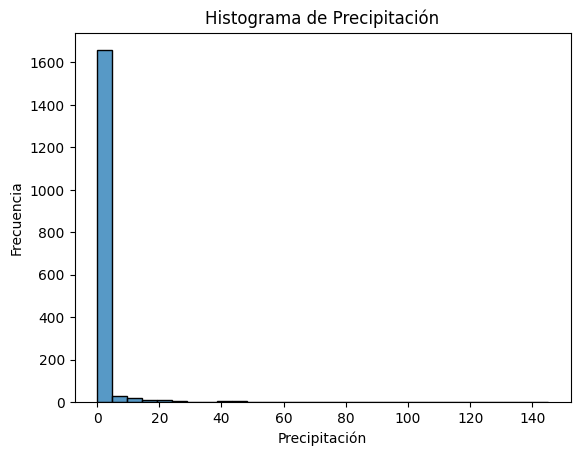

In [38]:
sns.histplot(df["PRECIP"].dropna(), bins=30)

plt.title("Histograma de Precipitación")
plt.xlabel("Precipitación")
plt.ylabel("Frecuencia")

plt.show()

El histograma muestra una distribución sesgada hacia la derecha.

La mayor parte de los registros presentan precipitaciones bajas, mientras que pocos registros alcanzan valores elevados.

In [26]:
pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -- ------------------------------------- 2.1/37.3 MB 5.9 MB/s eta 0:00:06
   ----- ---------------------------------- 5.5/37.3 MB 6.3 MB/s eta 0:00:06
   -------- ------------------------------- 8.4/37.3 MB 6.3 MB/s eta 0:00:05
   ------------- -------------------------- 12.6/37.3 MB 6.3 MB/s eta 0:00:04
   ----------------- ---------------------- 16.3/37.3 MB 6.4 MB/s eta 0:00:04
   ----------------------- ---------------- 22.3/37.3 MB 6.3 MB/s eta 0:00:03
   ---------------------------- ----------- 26.7/37.3 MB 6.3 MB/s eta 0:00:02
   ------------------------------- -------- 29.1/37.3 MB 6.3 MB/s eta 0:00:02
   ---------------------------------- ----- 32.0/37.3 MB 6.3 MB/s eta 0:00:01
   ------------------------------------- -- 35.4/37.3 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------  36.7/37.3 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------  37.2/37.3 MB 6.3 MB/s eta 0:00:


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


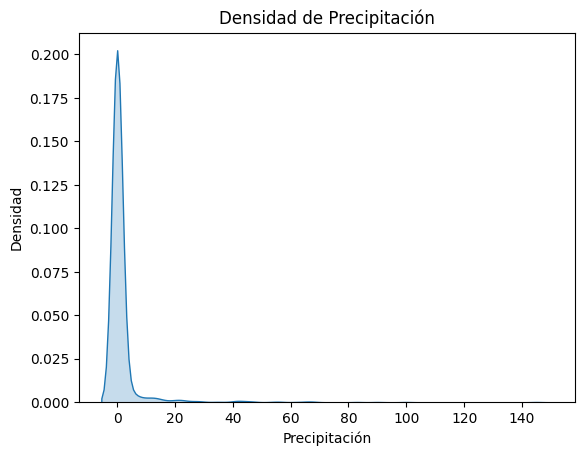

In [40]:
sns.kdeplot(df["PRECIP"].dropna(), fill=True)

plt.title("Densidad de Precipitación")
plt.xlabel("Precipitación")
plt.ylabel("Densidad")

plt.show()

# Interpretación de la densidad

La gráfica de densidad confirma que la mayor concentración de datos se encuentra en valores bajos de precipitación.

Esto indica que los días con lluvia intensa son menos frecuentes.

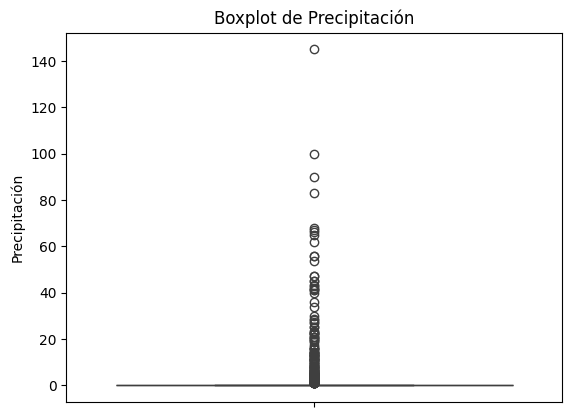

In [42]:
sns.boxplot(y=df["PRECIP"].dropna())
plt.title("Boxplot de Precipitación")
plt.ylabel("Precipitación")
plt.show()

El boxplot permite identificar la mediana, los cuartiles y múltiples valores atípicos presentes en la variable de precipitación.

Los puntos alejados representan eventos extremos de lluvia.

# Análisis temporal

Los datos analizados son de tipo temporal debido a que cada registro corresponde a una fecha específica.

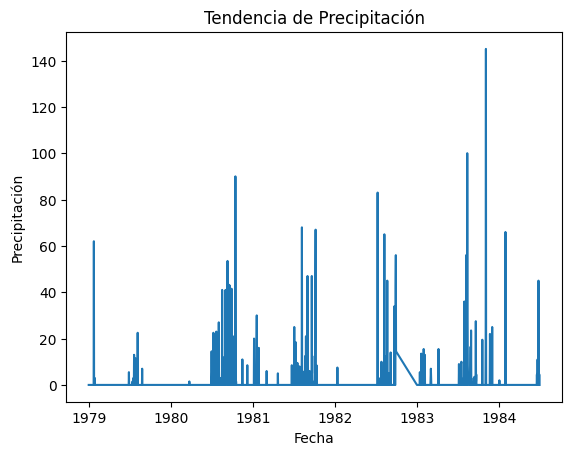

In [44]:
sns.lineplot(x=df["FECHA"], y=df["PRECIP"])

plt.title("Tendencia de Precipitación")
plt.xlabel("Fecha")
plt.ylabel("Precipitación")

plt.show()

La gráfica de línea muestra variaciones importantes en la precipitación a lo largo del tiempo.

Se observan periodos de baja precipitación y algunos incrementos relacionados con temporadas de lluvia intensa.

# Conclusiones

A través del análisis descriptivo realizado fue posible comprender el comportamiento de las variables climáticas registradas en la estación Lateral Diez (C25179).

Las medidas estadísticas y las gráficas facilitaron la identificación de tendencias, dispersión y valores atípicos en la precipitación.

Los resultados muestran que la mayoría de los registros presentan precipitaciones bajas, aunque existen algunos eventos extremos que generan una alta variabilidad en los datos.

El conjunto de datos resulta útil para estudios meteorológicos y climáticos relacionados con la ciudad de Culiacán.

Sin embargo, algunos registros presentan valores faltantes, lo cual representa una limitación dentro del análisis realizado.